# 04. Análisis de episodios potencialmente adversos

Este notebook analiza la frecuencia, duración y distribución temporal de condiciones de oleaje elevado a partir del archivo procesado `dataset_principal_oleaje.csv`.

El objetivo es transformar los registros horarios de altura significativa de ola, Hs, en indicadores que permitan identificar periodos de mayor exposición marítima.

El análisis combina umbrales absolutos y relativos. Los umbrales absolutos facilitan la interpretación mediante niveles comunes de Hs. Los umbrales relativos se calculan a partir de los percentiles históricos de cada boya y permiten adaptar el análisis al comportamiento de cada estación.

Los umbrales utilizados tienen una finalidad exclusivamente estadística y exploratoria. No se interpretan como criterios oficiales de cierre portuario, limitación operativa o seguridad de la navegación.



1. Cargar y comprobar el dataset principal de oleaje.
2. Definir umbrales absolutos de Hs.
3. Calcular umbrales relativos mediante percentiles por boya.
4. Cuantificar las horas por encima de cada umbral.
5. Identificar episodios continuados de oleaje elevado.
6. Calcular la duración media y máxima de los episodios.
7. Analizar su distribución mensual y anual.
8. Interpretar los indicadores desde la gestión portuaria.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
pd.set_option(
    "display.float_format",
    lambda x: f"{x:,.2f}"
)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [4]:
RUTA_DATASET = Path(
    "/content/dataset_principal_oleaje.csv"
)

dataset_principal_oleaje = pd.read_csv(
    RUTA_DATASET,
    parse_dates=["fecha"]
)

print("Dataset cargado correctamente.")
print("Archivo:", RUTA_DATASET.name)
print(
    "Número de registros:",
    f"{len(dataset_principal_oleaje):,}"
)
print(
    "Número de columnas:",
    dataset_principal_oleaje.shape[1]
)

Dataset cargado correctamente.
Archivo: dataset_principal_oleaje.csv
Número de registros: 610,438
Número de columnas: 14


In [5]:
display(
    dataset_principal_oleaje.head()
)

,fecha,codigo_boya,nombre_boya,zona,tipo_red,tipo_boya,Hs_m,H1_3_m,Hmax_m,Tm02_s,Tp_s,dir_media_oleaje_grados,dir_pico_oleaje_grados,dispersion_pico_grados
0,2005-01-01 00:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,1.70,1.61,2.36,7.99,11.71,329.00,326.00,31.00
1,2005-01-01 01:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,2.03,1.89,2.94,8.44,11.70,328.00,326.00,40.00
2,2005-01-01 02:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,1.87,1.77,2.54,8.39,11.76,327.00,326.00,36.00
3,2005-01-01 03:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,2.04,1.92,2.72,8.71,12.48,329.00,333.00,36.00
4,2005-01-01 04:00:00,1103,Bilbao costera,Bilbao,Red costera,Costera,1.92,1.82,2.59,8.60,11.79,324.00,325.00,45.00


Comprobación de variables fundamentales

In [7]:
variables_necesarias = [
    "fecha",
    "codigo_boya",
    "nombre_boya",
    "tipo_boya",
    "Hs_m"
]

print("COMPROBACIÓN DE VARIABLES")
print("-" * 45)

for variable in variables_necesarias:

    disponible = (
        variable in
        dataset_principal_oleaje.columns
    )

    print(
        variable,
        ":",
        "disponible" if disponible
        else "NO disponible"
    )

COMPROBACIÓN DE VARIABLES
---------------------------------------------
fecha : disponible
codigo_boya : disponible
nombre_boya : disponible
tipo_boya : disponible
Hs_m : disponible


In [8]:
FIGURES_DIR = Path(
    "/content/figures"
)

TABLES_DIR = Path(
    "/content/tables"
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Carpeta de figuras:",
    FIGURES_DIR
)

print(
    "Carpeta de tablas:",
    TABLES_DIR
)

Carpeta de figuras: /content/figures
Carpeta de tablas: /content/tables


PREPARACIÓN TEMPORAL

In [9]:
datos_episodios = (
    dataset_principal_oleaje.copy()
)

datos_episodios = (
    datos_episodios
    .sort_values(
        [
            "codigo_boya",
            "fecha"
        ]
    )
    .reset_index(drop=True)
)

print("Copia de trabajo creada.")
print(
    "Número de registros:",
    f"{len(datos_episodios):,}"
)

Copia de trabajo creada.
Número de registros: 610,438


Creación de variables temporales

In [10]:
datos_episodios["anio"] = (
    datos_episodios["fecha"].dt.year
)

datos_episodios["mes"] = (
    datos_episodios["fecha"].dt.month
)

datos_episodios["dia"] = (
    datos_episodios["fecha"].dt.day
)

datos_episodios["hora"] = (
    datos_episodios["fecha"].dt.hour
)

display(
    datos_episodios[
        [
            "fecha",
            "anio",
            "mes",
            "dia",
            "hora",
            "Hs_m"
        ]
    ].head()
)

,fecha,anio,mes,dia,hora,Hs_m
0,2005-01-01 00:00:00,2005,1,1,0,1.70
1,2005-01-01 01:00:00,2005,1,1,1,2.03
2,2005-01-01 02:00:00,2005,1,1,2,1.87
3,2005-01-01 03:00:00,2005,1,1,3,2.04
4,2005-01-01 04:00:00,2005,1,1,4,1.92


In [11]:
nombres_meses = {
    1: "Ene",
    2: "Feb",
    3: "Mar",
    4: "Abr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Ago",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dic"
}

orden_meses = [
    "Ene",
    "Feb",
    "Mar",
    "Abr",
    "May",
    "Jun",
    "Jul",
    "Ago",
    "Sep",
    "Oct",
    "Nov",
    "Dic"
]

datos_episodios["nombre_mes"] = (
    datos_episodios["mes"]
    .map(nombres_meses)
)

datos_episodios["nombre_mes"] = pd.Categorical(
    datos_episodios["nombre_mes"],
    categories=orden_meses,
    ordered=True
)

display(
    datos_episodios[
        [
            "fecha",
            "mes",
            "nombre_mes"
        ]
    ].head()
)

,fecha,mes,nombre_mes
0,2005-01-01 00:00:00,1,Ene
1,2005-01-01 01:00:00,1,Ene
2,2005-01-01 02:00:00,1,Ene
3,2005-01-01 03:00:00,1,Ene
4,2005-01-01 04:00:00,1,Ene


Revisar huecos temporales

Este control es importante porque para identificar un episodio continuado necesitamos distinguir entre:

*dos registros horarios consecutivos;y dos registros separados por varias horas debido a falta de datos.

In [12]:
datos_episodios["diferencia_horas"] = (
    datos_episodios
    .groupby("codigo_boya")["fecha"]
    .diff()
    .dt.total_seconds()
    / 3600
)

resumen_diferencias = (
    datos_episodios[
        "diferencia_horas"
    ]
    .describe()
)

display(resumen_diferencias)

,diferencia_horas
count,"610,434.00"
mean,1.15
std,24.38
min,1.00
25%,1.00
50%,1.00
75%,1.00
max,"14,330.00"


Análisis de los datos temporales obtenidos

In [13]:
saltos_temporales = (
    datos_episodios[
        datos_episodios["diferencia_horas"] > 1
    ]
    .groupby(
        [
            "codigo_boya",
            "nombre_boya"
        ],
        as_index=False
    )
    .agg(
        numero_saltos=(
            "diferencia_horas",
            "count"
        ),
        salto_medio_horas=(
            "diferencia_horas",
            "mean"
        ),
        salto_maximo_horas=(
            "diferencia_horas",
            "max"
        )
    )
)

saltos_temporales[
    [
        "salto_medio_horas",
        "salto_maximo_horas"
    ]
] = saltos_temporales[
    [
        "salto_medio_horas",
        "salto_maximo_horas"
    ]
].round(2)

display(saltos_temporales)

,codigo_boya,nombre_boya,numero_saltos,salto_medio_horas,salto_maximo_horas
0,1103,Bilbao costera,1527,23.48,"7,882.00"
1,1117,Gijón costera,451,55.31,"14,330.00"
2,2136,Bilbao-Vizcaya,455,28.53,"1,646.00"
3,2242,Cabo de Peñas,158,123.84,"2,861.00"


In [16]:
ruta_saltos_temporales = (
    TABLES_DIR / "tabla_saltos_temporales.csv"
)

saltos_temporales.to_csv(
    ruta_saltos_temporales,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_saltos_temporales)

Tabla guardada correctamente:
/content/tables/tabla_saltos_temporales.csv


Se debe localizar el salto máximo. Conviene identificar exactamente dónde está el salto de 14.330 horas

In [17]:
columnas_salto = [
    "codigo_boya",
    "nombre_boya",
    "fecha",
    "diferencia_horas"
]

saltos_mayores = (
    datos_episodios.loc[
        datos_episodios["diferencia_horas"] > 1,
        columnas_salto
    ]
    .sort_values(
        "diferencia_horas",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(saltos_mayores)

,codigo_boya,nombre_boya,fecha,diferencia_horas
0,1117,Gijón costera,2015-06-24 09:00:00,"14,330.00"
1,1103,Bilbao costera,2014-10-23 16:00:00,"7,882.00"
2,1103,Bilbao costera,2024-05-30 10:00:00,"4,442.00"
3,1103,Bilbao costera,2024-12-01 00:00:00,"3,763.00"
4,2242,Cabo de Peñas,2006-03-17 13:00:00,"2,861.00"
5,1103,Bilbao costera,2007-03-26 10:00:00,"2,610.00"
6,2242,Cabo de Peñas,2010-12-04 10:00:00,"2,345.00"
7,1103,Bilbao costera,2018-06-06 11:00:00,"1,829.00"
8,2242,Cabo de Peñas,2008-03-16 20:00:00,"1,681.00"
9,2136,Bilbao-Vizcaya,2009-04-02 22:00:00,"1,646.00"


La fecha mostrada anteriormente es  es la primera observación disponible después del hueco.

In [18]:
datos_episodios["fecha_anterior"] = (
    datos_episodios
    .groupby("codigo_boya")["fecha"]
    .shift(1)
)

detalle_saltos = (
    datos_episodios.loc[
        datos_episodios["diferencia_horas"] > 1,
        [
            "codigo_boya",
            "nombre_boya",
            "fecha_anterior",
            "fecha",
            "diferencia_horas"
        ]
    ]
    .sort_values(
        "diferencia_horas",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

display(detalle_saltos)

,codigo_boya,nombre_boya,fecha_anterior,fecha,diferencia_horas
0,1117,Gijón costera,2013-11-04 07:00:00,2015-06-24 09:00:00,"14,330.00"
1,1103,Bilbao costera,2013-11-29 06:00:00,2014-10-23 16:00:00,"7,882.00"
2,1103,Bilbao costera,2023-11-27 08:00:00,2024-05-30 10:00:00,"4,442.00"
3,1103,Bilbao costera,2024-06-27 05:00:00,2024-12-01 00:00:00,"3,763.00"
4,2242,Cabo de Peñas,2005-11-18 08:00:00,2006-03-17 13:00:00,"2,861.00"
5,1103,Bilbao costera,2006-12-07 16:00:00,2007-03-26 10:00:00,"2,610.00"
6,2242,Cabo de Peñas,2010-08-28 17:00:00,2010-12-04 10:00:00,"2,345.00"
7,1103,Bilbao costera,2018-03-22 06:00:00,2018-06-06 11:00:00,"1,829.00"
8,2242,Cabo de Peñas,2008-01-06 19:00:00,2008-03-16 20:00:00,"1,681.00"
9,2136,Bilbao-Vizcaya,2009-01-24 08:00:00,2009-04-02 22:00:00,"1,646.00"


In [19]:
ruta_detalle_saltos = (
    TABLES_DIR / "tabla_detalle_mayores_saltos.csv"
)

detalle_saltos.to_csv(
    ruta_detalle_saltos,
    index=False,
    encoding="utf-8-sig"
)

print("Detalle de saltos guardado:")
print(ruta_detalle_saltos)

Detalle de saltos guardado:
/content/tables/tabla_detalle_mayores_saltos.csv


### Interpretación de la continuidad temporal

La frecuencia habitual de las series es horaria, ya que la mediana y los percentiles 25 y 75 de la diferencia temporal son iguales a una hora. Sin embargo, se han identificado discontinuidades de distinta duración, incluyendo algunos intervalos prolongados sin datos.

Estos huecos no representan periodos sin oleaje, sino periodos sin observaciones disponibles. Por tanto, no deben contabilizarse como horas con condiciones normales ni utilizarse para prolongar artificialmente la duración de un episodio.

Para identificar episodios continuados, dos registros consecutivos por encima de un umbral se consideran parte del mismo episodio únicamente cuando están separados por una hora. Si existe una diferencia temporal superior, el registro posterior se considera el inicio de un nuevo episodio.

Se continua con la definición de umbrales y el cálculo de las horas observadas por encima de cada nivel.

## 2. Definición de umbrales de oleaje elevado

Para identificar condiciones de oleaje elevado se utilizan dos enfoques complementarios:

### Umbrales absolutos

- Hs ≥ 2 m: condición de oleaje moderado.
- Hs ≥ 3 m: condición potencialmente adversa.
- Hs ≥ 5 m: condición de oleaje severo.

Estos umbrales permiten aplicar niveles comunes a todas las boyas y facilitan la interpretación de los resultados.

### Umbrales relativos

- P90: valor superado por el 10 % de las observaciones válidas.
- P95: valor superado por el 5 % de las observaciones válidas.
- P99: valor superado por el 1 % de las observaciones válidas.

Los umbrales relativos se calculan por separado para cada boya. De esta manera, se tiene en cuenta el comportamiento histórico y el grado de exposición de cada estación.

Todos los umbrales utilizados tienen carácter estadístico y exploratorio. No representan criterios oficiales de cierre, restricción de operaciones o seguridad portuaria.

Creación de tablas

In [20]:
umbrales_absolutos = pd.DataFrame(
    {
        "nivel": [
            "Moderado",
            "Adverso exploratorio",
            "Severo exploratorio"
        ],
        "umbral_hs_m": [
            2.0,
            3.0,
            5.0
        ],
        "descripcion": [
            "Hs igual o superior a 2 metros",
            "Hs igual o superior a 3 metros",
            "Hs igual o superior a 5 metros"
        ]
    }
)

display(umbrales_absolutos)

,nivel,umbral_hs_m,descripcion
0,Moderado,2.00,Hs igual o superior a 2 metros
1,Adverso exploratorio,3.00,Hs igual o superior a 3 metros
2,Severo exploratorio,5.00,Hs igual o superior a 5 metros


In [22]:
ruta_umbrales_absolutos = (
    TABLES_DIR / "tabla_umbrales_absolutos.csv"
)

umbrales_absolutos.to_csv(
    ruta_umbrales_absolutos,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_umbrales_absolutos)

Tabla guardada correctamente:
/content/tables/tabla_umbrales_absolutos.csv


Cálculo de percentiles por boya

In [25]:
# Calcular los percentiles P90, P95 y P99 de Hs para cada boya

umbrales_relativos = (
    datos_episodios
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya"
        ]
    )["Hs_m"]
    .quantile(
        [
            0.90,
            0.95,
            0.99
        ]
    )
    .unstack()
    .reset_index()
)

# Cambiar los nombres de las columnas
umbrales_relativos = umbrales_relativos.rename(
    columns={
        0.90: "P90_m",
        0.95: "P95_m",
        0.99: "P99_m"
    }
)

# Redondear los resultados a dos decimales
umbrales_relativos[
    [
        "P90_m",
        "P95_m",
        "P99_m"
    ]
] = umbrales_relativos[
    [
        "P90_m",
        "P95_m",
        "P99_m"
    ]
].round(2)

# Ordenar por código de boya
umbrales_relativos = (
    umbrales_relativos
    .sort_values("codigo_boya")
    .reset_index(drop=True)
)

# Mostrar la tabla
display(umbrales_relativos)

,codigo_boya,nombre_boya,tipo_boya,P90_m,P95_m,P99_m
0,1103,Bilbao costera,Costera,2.57,3.11,4.35
1,1117,Gijón costera,Costera,2.79,3.34,4.62
2,2136,Bilbao-Vizcaya,Exterior,3.62,4.44,6.34
3,2242,Cabo de Peñas,Exterior,3.60,4.31,6.10


In [26]:
ruta_umbrales_relativos = (
    TABLES_DIR /
    "tabla_umbrales_relativos_por_boya.csv"
)

umbrales_relativos.to_csv(
    ruta_umbrales_relativos,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_umbrales_relativos)

Tabla guardada correctamente:
/content/tables/tabla_umbrales_relativos_por_boya.csv


In [27]:
print(
    "¿Existe el archivo?",
    ruta_umbrales_relativos.exists()
)

print(
    "Número de boyas:",
    len(umbrales_relativos)
)

¿Existe el archivo? True
Número de boyas: 4


Horas por encima de los umbrales absolutos

Se crean los umbrales de superación

In [28]:
datos_episodios["Hs_ge_2m"] = (
    datos_episodios["Hs_m"] >= 2
)

datos_episodios["Hs_ge_3m"] = (
    datos_episodios["Hs_m"] >= 3
)

datos_episodios["Hs_ge_5m"] = (
    datos_episodios["Hs_m"] >= 5
)

display(
    datos_episodios[
        [
            "fecha",
            "nombre_boya",
            "Hs_m",
            "Hs_ge_2m",
            "Hs_ge_3m",
            "Hs_ge_5m"
        ]
    ].head(10)
)

,fecha,nombre_boya,Hs_m,Hs_ge_2m,Hs_ge_3m,Hs_ge_5m
0,2005-01-01 00:00:00,Bilbao costera,1.70,False,False,False
1,2005-01-01 01:00:00,Bilbao costera,2.03,True,False,False
2,2005-01-01 02:00:00,Bilbao costera,1.87,False,False,False
3,2005-01-01 03:00:00,Bilbao costera,2.04,True,False,False
4,2005-01-01 04:00:00,Bilbao costera,1.92,False,False,False
5,2005-01-01 05:00:00,Bilbao costera,1.95,False,False,False
6,2005-01-01 06:00:00,Bilbao costera,2.03,True,False,False
7,2005-01-01 07:00:00,Bilbao costera,1.93,False,False,False
8,2005-01-01 08:00:00,Bilbao costera,1.86,False,False,False
9,2005-01-01 09:00:00,Bilbao costera,1.72,False,False,False


Cálculo de horas superadas sobre cada umbral

In [29]:
tabla_horas_umbral_hs = (
    datos_episodios
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya"
        ],
        as_index=False
    )
    .agg(
        registros_validos=(
            "Hs_m",
            "count"
        ),
        horas_Hs_ge_2m=(
            "Hs_ge_2m",
            "sum"
        ),
        horas_Hs_ge_3m=(
            "Hs_ge_3m",
            "sum"
        ),
        horas_Hs_ge_5m=(
            "Hs_ge_5m",
            "sum"
        )
    )
)

display(tabla_horas_umbral_hs)

,codigo_boya,nombre_boya,tipo_boya,registros_validos,horas_Hs_ge_2m,horas_Hs_ge_3m,horas_Hs_ge_5m
0,1103,Bilbao costera,Costera,140988,27713,8086,519
1,1117,Gijón costera,Costera,150719,39370,11694,903
2,2136,Bilbao-Vizcaya,Exterior,162789,58269,26292,5124
3,2242,Cabo de Peñas,Exterior,155935,61997,26460,4156


Como la frecuencia habitual es horaria, cada registro marcado como True se contabiliza como una hora observada por encima del umbral.

Cálculo de los porcentajes:

In [30]:
tabla_horas_umbral_hs["pct_Hs_ge_2m"] = (
    tabla_horas_umbral_hs["horas_Hs_ge_2m"]
    / tabla_horas_umbral_hs["registros_validos"]
    * 100
).round(2)

tabla_horas_umbral_hs["pct_Hs_ge_3m"] = (
    tabla_horas_umbral_hs["horas_Hs_ge_3m"]
    / tabla_horas_umbral_hs["registros_validos"]
    * 100
).round(2)

tabla_horas_umbral_hs["pct_Hs_ge_5m"] = (
    tabla_horas_umbral_hs["horas_Hs_ge_5m"]
    / tabla_horas_umbral_hs["registros_validos"]
    * 100
).round(2)

display(tabla_horas_umbral_hs)

,codigo_boya,nombre_boya,tipo_boya,registros_validos,horas_Hs_ge_2m,horas_Hs_ge_3m,horas_Hs_ge_5m,pct_Hs_ge_2m,pct_Hs_ge_3m,pct_Hs_ge_5m
0,1103,Bilbao costera,Costera,140988,27713,8086,519,19.66,5.74,0.37
1,1117,Gijón costera,Costera,150719,39370,11694,903,26.12,7.76,0.60
2,2136,Bilbao-Vizcaya,Exterior,162789,58269,26292,5124,35.79,16.15,3.15
3,2242,Cabo de Peñas,Exterior,155935,61997,26460,4156,39.76,16.97,2.67


In [31]:
ruta_horas_umbral = (
    TABLES_DIR /
    "tabla_horas_umbral_hs.csv"
)

tabla_horas_umbral_hs.to_csv(
    ruta_horas_umbral,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_horas_umbral)

Tabla guardada correctamente:
/content/tables/tabla_horas_umbral_hs.csv


Se prepara la tabla para los distintos gráficos

In [32]:
horas_umbral_largo = (
    tabla_horas_umbral_hs
    .melt(
        id_vars=[
            "codigo_boya",
            "nombre_boya",
            "tipo_boya"
        ],
        value_vars=[
            "horas_Hs_ge_2m",
            "horas_Hs_ge_3m",
            "horas_Hs_ge_5m"
        ],
        var_name="umbral",
        value_name="horas"
    )
)

horas_umbral_largo["umbral"] = (
    horas_umbral_largo["umbral"]
    .replace(
        {
            "horas_Hs_ge_2m": "Hs ≥ 2 m",
            "horas_Hs_ge_3m": "Hs ≥ 3 m",
            "horas_Hs_ge_5m": "Hs ≥ 5 m"
        }
    )
)

display(horas_umbral_largo.head())

,codigo_boya,nombre_boya,tipo_boya,umbral,horas
0,1103,Bilbao costera,Costera,Hs ≥ 2 m,27713
1,1117,Gijón costera,Costera,Hs ≥ 2 m,39370
2,2136,Bilbao-Vizcaya,Exterior,Hs ≥ 2 m,58269
3,2242,Cabo de Peñas,Exterior,Hs ≥ 2 m,61997
4,1103,Bilbao costera,Costera,Hs ≥ 3 m,8086


Se crea el gráfico de horas por umbral

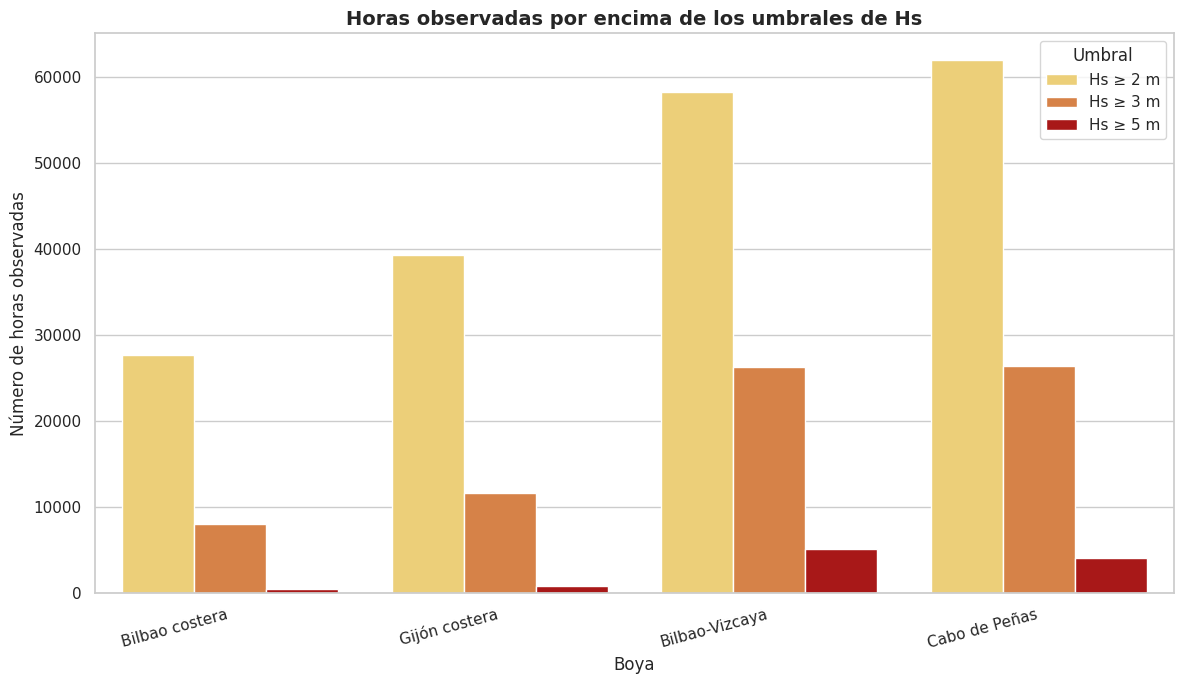

Figura guardada correctamente:
/content/figures/horas_por_encima_umbrales_hs.png


In [33]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=horas_umbral_largo,
    x="nombre_boya",
    y="horas",
    hue="umbral",
    palette=[
        "#FFD966",
        "#ED7D31",
        "#C00000"
    ]
)

plt.title(
    "Horas observadas por encima de los umbrales de Hs",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Boya")
plt.ylabel("Número de horas observadas")
plt.xticks(rotation=15, ha="right")

plt.legend(
    title="Umbral"
)

plt.tight_layout()

ruta_figura_horas = (
    FIGURES_DIR /
    "horas_por_encima_umbrales_hs.png"
)

plt.savefig(
    ruta_figura_horas,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada correctamente:")
print(ruta_figura_horas)

Detección de episodios continuados

## 3. Identificación de episodios continuados

Una hora por encima de un umbral no equivale necesariamente a un episodio independiente. Varias horas consecutivas pueden pertenecer al mismo evento.

En este análisis, un episodio comienza cuando Hs alcanza o supera el umbral seleccionado. El episodio continúa mientras:

- los registros siguientes mantengan Hs por encima del umbral;
- y la distancia temporal entre registros consecutivos sea exactamente de una hora.

El episodio termina cuando Hs desciende por debajo del umbral o aparece un hueco temporal superior a una hora.

La duración se expresa como el número de observaciones horarias consecutivas que forman el episodio. Este criterio evita contabilizar como duración los intervalos en los que no existen datos.

Se crea la función de identificación de episodios

In [34]:
def detectar_episodios(
    dataframe,
    columna_superacion,
    nombre_umbral,
    valor_umbral
):

    episodios = []

    for codigo_boya, grupo in dataframe.groupby(
        "codigo_boya"
    ):

        grupo = (
            grupo
            .sort_values("fecha")
            .copy()
        )

        supera = grupo[columna_superacion].fillna(False)

        inicia_episodio = (
            supera
            & (
                ~supera.shift(1, fill_value=False)
                | (grupo["diferencia_horas"] != 1)
            )
        )

        grupo["id_episodio"] = (
            inicia_episodio.cumsum()
        )

        registros_superados = grupo[supera].copy()

        if registros_superados.empty:
            continue

        resumen = (
            registros_superados
            .groupby(
                "id_episodio",
                as_index=False
            )
            .agg(
                codigo_boya=(
                    "codigo_boya",
                    "first"
                ),
                nombre_boya=(
                    "nombre_boya",
                    "first"
                ),
                tipo_boya=(
                    "tipo_boya",
                    "first"
                ),
                fecha_inicio=(
                    "fecha",
                    "min"
                ),
                fecha_fin=(
                    "fecha",
                    "max"
                ),
                duracion_horas=(
                    "fecha",
                    "size"
                ),
                Hs_media_m=(
                    "Hs_m",
                    "mean"
                ),
                Hs_maxima_m=(
                    "Hs_m",
                    "max"
                )
            )
        )

        resumen["umbral"] = nombre_umbral
        resumen["umbral_hs_m"] = valor_umbral

        episodios.append(resumen)

    if episodios:
        resultado = pd.concat(
            episodios,
            ignore_index=True
        )
    else:
        resultado = pd.DataFrame()

    return resultado

Detectar los episodios de Hs ≥ 2 m

In [35]:
episodios_2m = detectar_episodios(
    datos_episodios,
    "Hs_ge_2m",
    "Hs ≥ 2 m",
    2.0
)

print(
    "Episodios detectados para Hs ≥ 2 m:",
    len(episodios_2m)
)

display(episodios_2m.head())

Episodios detectados para Hs ≥ 2 m: 12205


,id_episodio,codigo_boya,nombre_boya,tipo_boya,fecha_inicio,fecha_fin,duracion_horas,Hs_media_m,Hs_maxima_m,umbral,umbral_hs_m
0,1,1103,Bilbao costera,Costera,2005-01-01 01:00:00,2005-01-01 01:00:00,1,2.03,2.03,Hs ≥ 2 m,2.00
1,2,1103,Bilbao costera,Costera,2005-01-01 03:00:00,2005-01-01 03:00:00,1,2.04,2.04,Hs ≥ 2 m,2.00
2,3,1103,Bilbao costera,Costera,2005-01-01 06:00:00,2005-01-01 06:00:00,1,2.03,2.03,Hs ≥ 2 m,2.00
3,4,1103,Bilbao costera,Costera,2005-01-02 16:00:00,2005-01-02 17:00:00,2,2.49,2.58,Hs ≥ 2 m,2.00
4,5,1103,Bilbao costera,Costera,2005-01-02 21:00:00,2005-01-02 21:00:00,1,2.83,2.83,Hs ≥ 2 m,2.00


Detectar los episodios de Hs ≥ 3 m

In [36]:
episodios_3m = detectar_episodios(
    datos_episodios,
    "Hs_ge_3m",
    "Hs ≥ 3 m",
    3.0
)

print(
    "Episodios detectados para Hs ≥ 3 m:",
    len(episodios_3m)
)

display(episodios_3m.head())

Episodios detectados para Hs ≥ 3 m: 6842


,id_episodio,codigo_boya,nombre_boya,tipo_boya,fecha_inicio,fecha_fin,duracion_horas,Hs_media_m,Hs_maxima_m,umbral,umbral_hs_m
0,1,1103,Bilbao costera,Costera,2005-01-03 00:00:00,2005-01-03 00:00:00,1,3.00,3.00,Hs ≥ 3 m,3.00
1,2,1103,Bilbao costera,Costera,2005-01-03 02:00:00,2005-01-03 06:00:00,5,3.29,3.52,Hs ≥ 3 m,3.00
2,3,1103,Bilbao costera,Costera,2005-01-03 10:00:00,2005-01-03 10:00:00,1,3.13,3.13,Hs ≥ 3 m,3.00
3,4,1103,Bilbao costera,Costera,2005-01-06 16:00:00,2005-01-06 16:00:00,1,3.17,3.17,Hs ≥ 3 m,3.00
4,5,1103,Bilbao costera,Costera,2005-01-12 17:00:00,2005-01-12 19:00:00,3,3.40,3.58,Hs ≥ 3 m,3.00


 Detectar los episodios de Hs ≥ 5 m

In [37]:
episodios_5m = detectar_episodios(
    datos_episodios,
    "Hs_ge_5m",
    "Hs ≥ 5 m",
    5.0
)

print(
    "Episodios detectados para Hs ≥ 5 m:",
    len(episodios_5m)
)

display(episodios_5m.head())

Episodios detectados para Hs ≥ 5 m: 1682


,id_episodio,codigo_boya,nombre_boya,tipo_boya,fecha_inicio,fecha_fin,duracion_horas,Hs_media_m,Hs_maxima_m,umbral,umbral_hs_m
0,1,1103,Bilbao costera,Costera,2005-02-13 22:00:00,2005-02-13 23:00:00,2,5.50,5.63,Hs ≥ 5 m,5.00
1,2,1103,Bilbao costera,Costera,2006-03-05 01:00:00,2006-03-05 01:00:00,1,5.28,5.28,Hs ≥ 5 m,5.00
2,3,1103,Bilbao costera,Costera,2007-05-20 03:00:00,2007-05-20 03:00:00,1,5.07,5.07,Hs ≥ 5 m,5.00
3,4,1103,Bilbao costera,Costera,2007-05-28 08:00:00,2007-05-28 08:00:00,1,5.10,5.10,Hs ≥ 5 m,5.00
4,5,1103,Bilbao costera,Costera,2007-12-02 07:00:00,2007-12-02 07:00:00,1,5.00,5.00,Hs ≥ 5 m,5.00


Unión de todos los episodios absolutos

In [38]:
episodios_absolutos = pd.concat(
    [
        episodios_2m,
        episodios_3m,
        episodios_5m
    ],
    ignore_index=True
)

episodios_absolutos[
    [
        "Hs_media_m",
        "Hs_maxima_m"
    ]
] = episodios_absolutos[
    [
        "Hs_media_m",
        "Hs_maxima_m"
    ]
].round(2)

episodios_absolutos["anio_inicio"] = (
    episodios_absolutos["fecha_inicio"].dt.year
)

episodios_absolutos["mes_inicio"] = (
    episodios_absolutos["fecha_inicio"].dt.month
)

episodios_absolutos["nombre_mes_inicio"] = (
    episodios_absolutos["mes_inicio"]
    .map(nombres_meses)
)

display(episodios_absolutos.head())

,id_episodio,codigo_boya,nombre_boya,tipo_boya,fecha_inicio,fecha_fin,duracion_horas,Hs_media_m,Hs_maxima_m,umbral,umbral_hs_m,anio_inicio,mes_inicio,nombre_mes_inicio
0,1,1103,Bilbao costera,Costera,2005-01-01 01:00:00,2005-01-01 01:00:00,1,2.03,2.03,Hs ≥ 2 m,2.00,2005,1,Ene
1,2,1103,Bilbao costera,Costera,2005-01-01 03:00:00,2005-01-01 03:00:00,1,2.04,2.04,Hs ≥ 2 m,2.00,2005,1,Ene
2,3,1103,Bilbao costera,Costera,2005-01-01 06:00:00,2005-01-01 06:00:00,1,2.03,2.03,Hs ≥ 2 m,2.00,2005,1,Ene
3,4,1103,Bilbao costera,Costera,2005-01-02 16:00:00,2005-01-02 17:00:00,2,2.49,2.58,Hs ≥ 2 m,2.00,2005,1,Ene
4,5,1103,Bilbao costera,Costera,2005-01-02 21:00:00,2005-01-02 21:00:00,1,2.83,2.83,Hs ≥ 2 m,2.00,2005,1,Ene


In [39]:
ruta_episodios_absolutos = (
    TABLES_DIR /
    "tabla_episodios_adversos.csv"
)

episodios_absolutos.to_csv(
    ruta_episodios_absolutos,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_episodios_absolutos)

Tabla guardada correctamente:
/content/tables/tabla_episodios_adversos.csv


Resumen de frecuencia y duración

Calculo resumen de episodios

In [40]:
tabla_resumen_episodios = (
    episodios_absolutos
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "umbral",
            "umbral_hs_m"
        ],
        as_index=False
    )
    .agg(
        numero_episodios=(
            "fecha_inicio",
            "count"
        ),
        duracion_media_horas=(
            "duracion_horas",
            "mean"
        ),
        duracion_mediana_horas=(
            "duracion_horas",
            "median"
        ),
        duracion_maxima_horas=(
            "duracion_horas",
            "max"
        ),
        Hs_maxima_episodio_m=(
            "Hs_maxima_m",
            "max"
        )
    )
)

tabla_resumen_episodios[
    [
        "duracion_media_horas",
        "duracion_mediana_horas",
        "Hs_maxima_episodio_m"
    ]
] = tabla_resumen_episodios[
    [
        "duracion_media_horas",
        "duracion_mediana_horas",
        "Hs_maxima_episodio_m"
    ]
].round(2)

display(tabla_resumen_episodios)

,codigo_boya,nombre_boya,tipo_boya,umbral,umbral_hs_m,numero_episodios,duracion_media_horas,duracion_mediana_horas,duracion_maxima_horas,Hs_maxima_episodio_m
0,1103,Bilbao costera,Costera,Hs ≥ 2 m,2.00,2504,11.07,2.00,224,8.37
1,1103,Bilbao costera,Costera,Hs ≥ 3 m,3.00,1063,7.61,2.00,100,8.37
2,1103,Bilbao costera,Costera,Hs ≥ 5 m,5.00,122,4.25,1.00,32,8.37
3,1117,Gijón costera,Costera,Hs ≥ 2 m,2.00,3201,12.30,2.00,346,8.98
4,1117,Gijón costera,Costera,Hs ≥ 3 m,3.00,1561,7.49,2.00,129,8.98
5,1117,Gijón costera,Costera,Hs ≥ 5 m,5.00,232,3.89,2.00,35,8.98
6,2136,Bilbao-Vizcaya,Exterior,Hs ≥ 2 m,2.00,3252,17.92,3.00,455,13.72
7,2136,Bilbao-Vizcaya,Exterior,Hs ≥ 3 m,3.00,2074,12.68,2.00,271,13.72
8,2136,Bilbao-Vizcaya,Exterior,Hs ≥ 5 m,5.00,703,7.29,2.00,93,13.72
9,2242,Cabo de Peñas,Exterior,Hs ≥ 2 m,2.00,3248,19.09,3.00,917,12.18


In [41]:
ruta_resumen_episodios = (
    TABLES_DIR /
    "tabla_resumen_episodios.csv"
)

tabla_resumen_episodios.to_csv(
    ruta_resumen_episodios,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada correctamente:")
print(ruta_resumen_episodios)

Tabla guardada correctamente:
/content/tables/tabla_resumen_episodios.csv


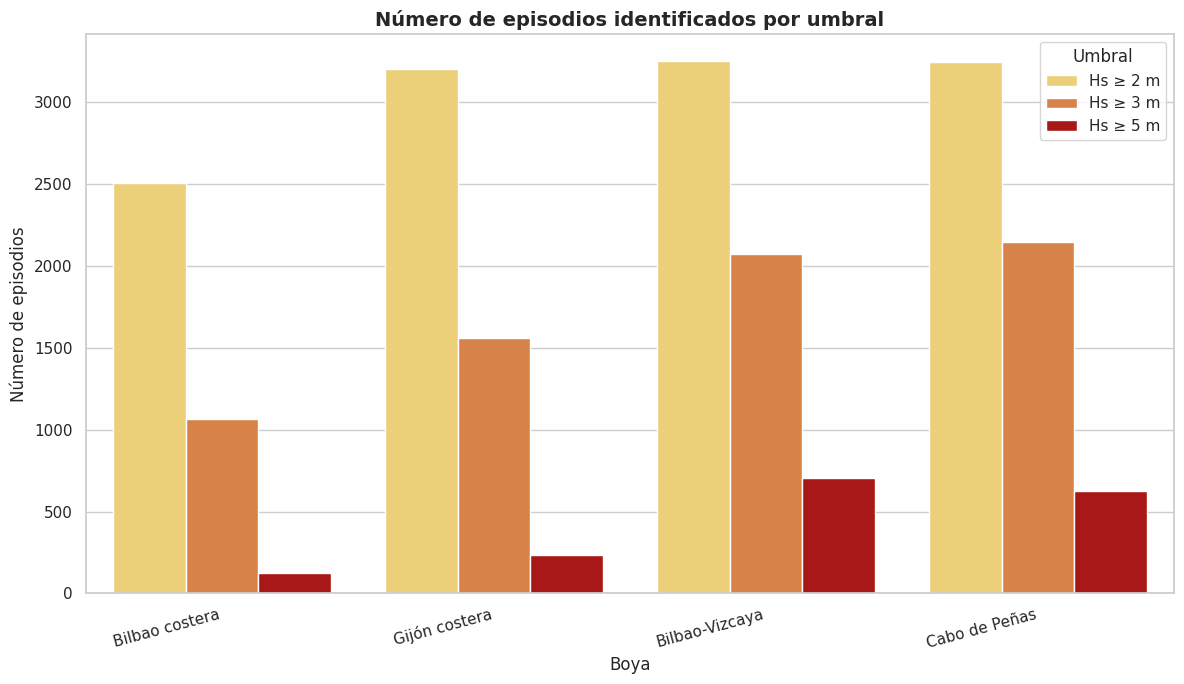

Figura guardada:
/content/figures/numero_episodios_por_umbral.png


In [42]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=tabla_resumen_episodios,
    x="nombre_boya",
    y="numero_episodios",
    hue="umbral",
    palette=[
        "#FFD966",
        "#ED7D31",
        "#C00000"
    ]
)

plt.title(
    "Número de episodios identificados por umbral",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Boya")
plt.ylabel("Número de episodios")
plt.xticks(rotation=15, ha="right")

plt.legend(
    title="Umbral"
)

plt.tight_layout()

ruta_numero_episodios = (
    FIGURES_DIR /
    "numero_episodios_por_umbral.png"
)

plt.savefig(
    ruta_numero_episodios,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_numero_episodios)

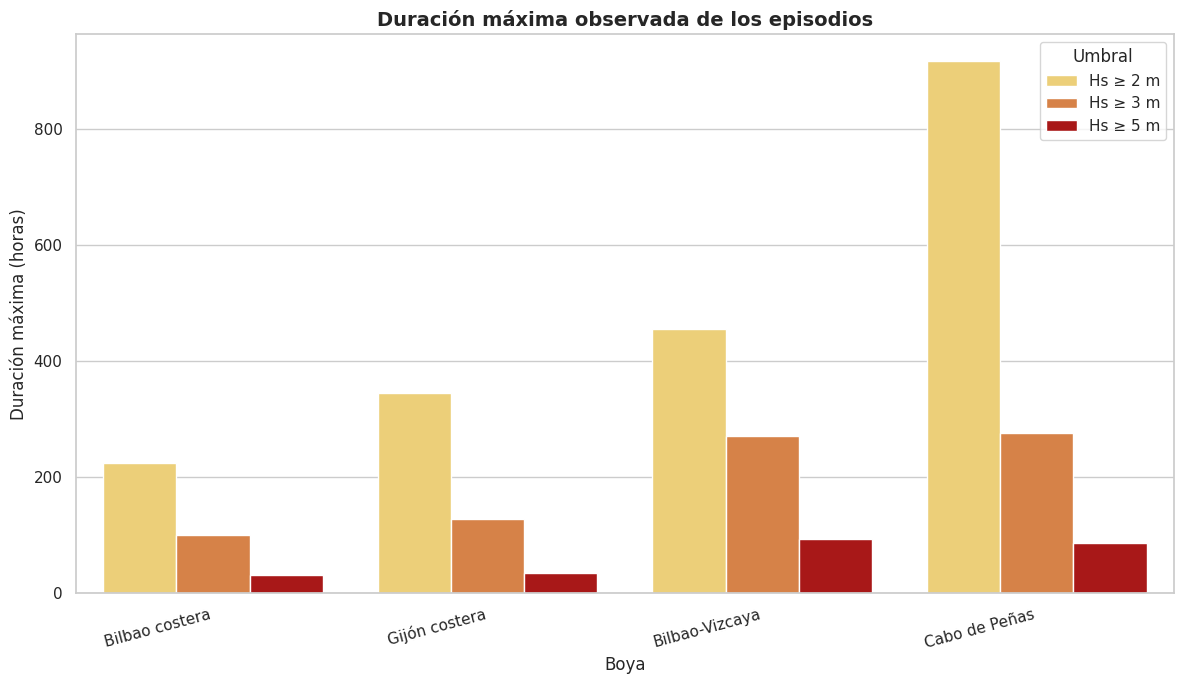

Figura guardada:
/content/figures/duracion_maxima_episodios.png


In [43]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=tabla_resumen_episodios,
    x="nombre_boya",
    y="duracion_maxima_horas",
    hue="umbral",
    palette=[
        "#FFD966",
        "#ED7D31",
        "#C00000"
    ]
)

plt.title(
    "Duración máxima observada de los episodios",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Boya")
plt.ylabel("Duración máxima (horas)")
plt.xticks(rotation=15, ha="right")

plt.legend(
    title="Umbral"
)

plt.tight_layout()

ruta_duracion_maxima = (
    FIGURES_DIR /
    "duracion_maxima_episodios.png"
)

plt.savefig(
    ruta_duracion_maxima,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_duracion_maxima)

Distribución mensual y anual

In [44]:
tabla_episodios_mensuales = (
    episodios_absolutos
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "umbral",
            "mes_inicio",
            "nombre_mes_inicio"
        ],
        as_index=False
    )
    .agg(
        numero_episodios=(
            "fecha_inicio",
            "count"
        ),
        horas_totales_episodios=(
            "duracion_horas",
            "sum"
        ),
        duracion_maxima_horas=(
            "duracion_horas",
            "max"
        )
    )
)

tabla_episodios_mensuales = (
    tabla_episodios_mensuales
    .sort_values(
        [
            "codigo_boya",
            "umbral",
            "mes_inicio"
        ]
    )
    .reset_index(drop=True)
)

display(tabla_episodios_mensuales.head())


,codigo_boya,nombre_boya,umbral,mes_inicio,nombre_mes_inicio,numero_episodios,horas_totales_episodios,duracion_maxima_horas
0,1103,Bilbao costera,Hs ≥ 2 m,1,Ene,260,3727,224
1,1103,Bilbao costera,Hs ≥ 2 m,2,Feb,236,3692,169
2,1103,Bilbao costera,Hs ≥ 2 m,3,Mar,289,3253,131
3,1103,Bilbao costera,Hs ≥ 2 m,4,Abr,212,1364,56
4,1103,Bilbao costera,Hs ≥ 2 m,5,May,138,1025,82


In [45]:
ruta_episodios_mensuales = (
    TABLES_DIR /
    "tabla_episodios_mensuales.csv"
)

tabla_episodios_mensuales.to_csv(
    ruta_episodios_mensuales,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada:")
print(ruta_episodios_mensuales)

Tabla guardada:
/content/tables/tabla_episodios_mensuales.csv


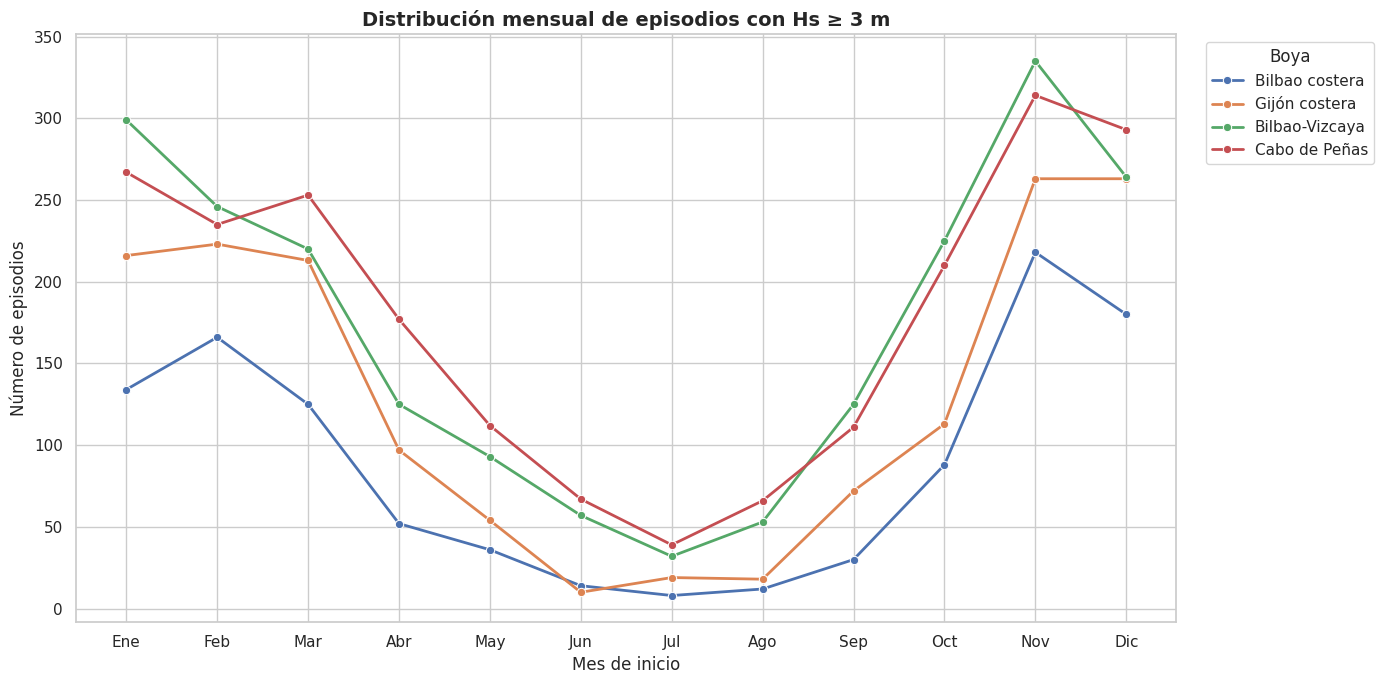

Figura guardada:
/content/figures/episodios_mensuales_hs_ge_3m.png


In [46]:
datos_mensuales_3m = (
    tabla_episodios_mensuales[
        tabla_episodios_mensuales["umbral"]
        == "Hs ≥ 3 m"
    ]
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=datos_mensuales_3m,
    x="nombre_mes_inicio",
    y="numero_episodios",
    hue="nombre_boya",
    marker="o",
    linewidth=2
)

plt.title(
    "Distribución mensual de episodios con Hs ≥ 3 m",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Mes de inicio")
plt.ylabel("Número de episodios")

plt.legend(
    title="Boya",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ruta_episodios_mensuales_figura = (
    FIGURES_DIR /
    "episodios_mensuales_hs_ge_3m.png"
)

plt.savefig(
    ruta_episodios_mensuales_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_episodios_mensuales_figura)

In [47]:
tabla_episodios_anuales = (
    episodios_absolutos
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "umbral",
            "anio_inicio"
        ],
        as_index=False
    )
    .agg(
        numero_episodios=(
            "fecha_inicio",
            "count"
        ),
        horas_totales_episodios=(
            "duracion_horas",
            "sum"
        ),
        duracion_maxima_horas=(
            "duracion_horas",
            "max"
        ),
        Hs_maxima_m=(
            "Hs_maxima_m",
            "max"
        )
    )
)

display(tabla_episodios_anuales.head())

,codigo_boya,nombre_boya,umbral,anio_inicio,numero_episodios,horas_totales_episodios,duracion_maxima_horas,Hs_maxima_m
0,1103,Bilbao costera,Hs ≥ 2 m,2005,124,1191,169,5.63
1,1103,Bilbao costera,Hs ≥ 2 m,2006,117,672,166,5.28
2,1103,Bilbao costera,Hs ≥ 2 m,2007,95,848,130,8.37
3,1103,Bilbao costera,Hs ≥ 2 m,2008,175,2308,131,8.19
4,1103,Bilbao costera,Hs ≥ 2 m,2009,114,1579,191,7.00


In [48]:
ruta_episodios_anuales = (
    TABLES_DIR /
    "tabla_episodios_anuales.csv"
)

tabla_episodios_anuales.to_csv(
    ruta_episodios_anuales,
    index=False,
    encoding="utf-8-sig"
)

print("Tabla guardada:")
print(ruta_episodios_anuales)

Tabla guardada:
/content/tables/tabla_episodios_anuales.csv


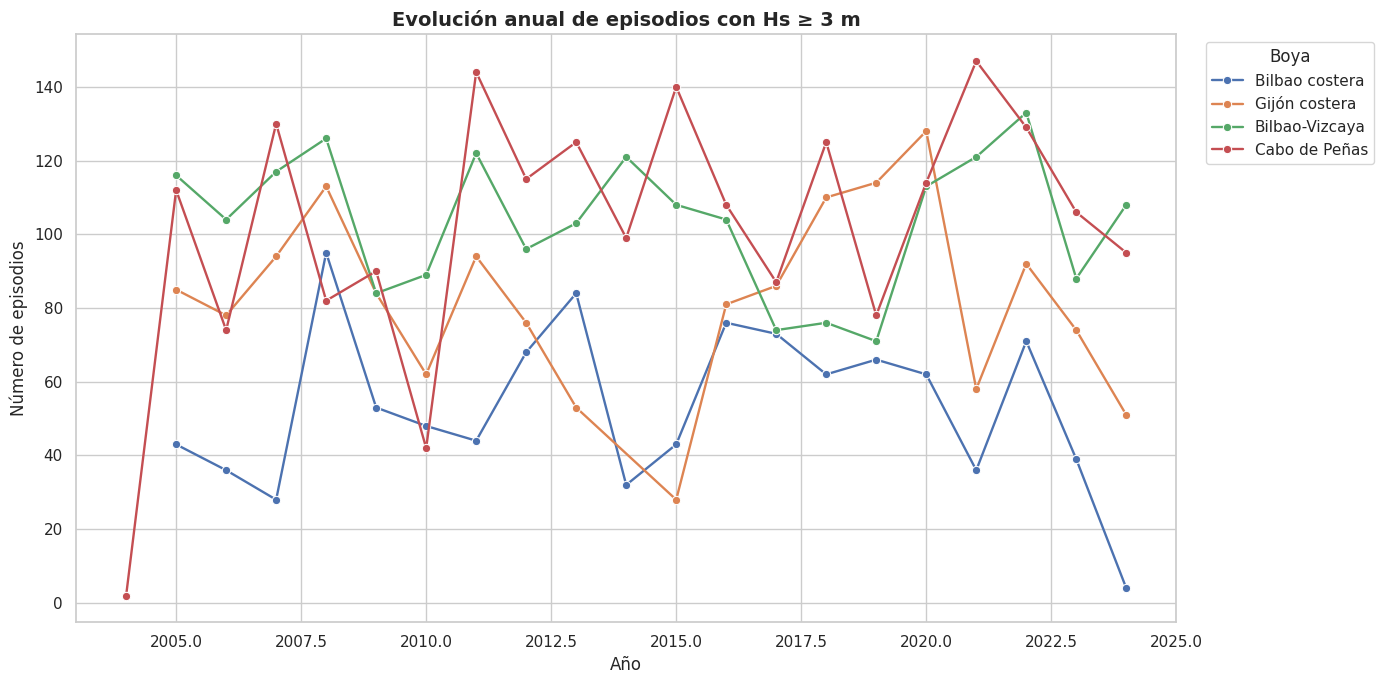

Figura guardada:
/content/figures/episodios_anuales_hs_ge_3m.png


In [49]:
datos_anuales_3m = (
    tabla_episodios_anuales[
        tabla_episodios_anuales["umbral"]
        == "Hs ≥ 3 m"
    ]
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=datos_anuales_3m,
    x="anio_inicio",
    y="numero_episodios",
    hue="nombre_boya",
    marker="o",
    linewidth=1.7
)

plt.title(
    "Evolución anual de episodios con Hs ≥ 3 m",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Año")
plt.ylabel("Número de episodios")

plt.legend(
    title="Boya",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ruta_episodios_anuales_figura = (
    FIGURES_DIR /
    "episodios_anuales_hs_ge_3m.png"
)

plt.savefig(
    ruta_episodios_anuales_figura,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada:")
print(ruta_episodios_anuales_figura)

Episodios relativos por P95

Se usa el el P95 como umbral relativo principal. Las tablas P90 y P99 se conservan como referencias.

Se incorpora P95 a cada registro

In [50]:
datos_episodios = datos_episodios.merge(
    umbrales_relativos[
        [
            "codigo_boya",
            "P90_m",
            "P95_m",
            "P99_m"
        ]
    ],
    on="codigo_boya",
    how="left"
)

datos_episodios["Hs_ge_P95"] = (
    datos_episodios["Hs_m"]
    >= datos_episodios["P95_m"]
)

display(
    datos_episodios[
        [
            "fecha",
            "nombre_boya",
            "Hs_m",
            "P95_m",
            "Hs_ge_P95"
        ]
    ].head()
)

,fecha,nombre_boya,Hs_m,P95_m,Hs_ge_P95
0,2005-01-01 00:00:00,Bilbao costera,1.70,3.11,False
1,2005-01-01 01:00:00,Bilbao costera,2.03,3.11,False
2,2005-01-01 02:00:00,Bilbao costera,1.87,3.11,False
3,2005-01-01 03:00:00,Bilbao costera,2.04,3.11,False
4,2005-01-01 04:00:00,Bilbao costera,1.92,3.11,False


Detección de episodios sobre P95

In [51]:
lista_episodios_p95 = []

for codigo_boya, grupo in datos_episodios.groupby(
    "codigo_boya"
):

    valor_p95 = grupo["P95_m"].iloc[0]

    episodios_boya = detectar_episodios(
        grupo,
        "Hs_ge_P95",
        "Hs ≥ P95",
        valor_p95
    )

    lista_episodios_p95.append(
        episodios_boya
    )

episodios_p95 = pd.concat(
    lista_episodios_p95,
    ignore_index=True
)

episodios_p95[
    [
        "Hs_media_m",
        "Hs_maxima_m",
        "umbral_hs_m"
    ]
] = episodios_p95[
    [
        "Hs_media_m",
        "Hs_maxima_m",
        "umbral_hs_m"
    ]
].round(2)

display(episodios_p95.head())

,id_episodio,codigo_boya,nombre_boya,tipo_boya,fecha_inicio,fecha_fin,duracion_horas,Hs_media_m,Hs_maxima_m,umbral,umbral_hs_m
0,1,1103,Bilbao costera,Costera,2005-01-03 02:00:00,2005-01-03 04:00:00,3,3.35,3.52,Hs ≥ P95,3.11
1,2,1103,Bilbao costera,Costera,2005-01-03 06:00:00,2005-01-03 06:00:00,1,3.33,3.33,Hs ≥ P95,3.11
2,3,1103,Bilbao costera,Costera,2005-01-03 10:00:00,2005-01-03 10:00:00,1,3.13,3.13,Hs ≥ P95,3.11
3,4,1103,Bilbao costera,Costera,2005-01-06 16:00:00,2005-01-06 16:00:00,1,3.17,3.17,Hs ≥ P95,3.11
4,5,1103,Bilbao costera,Costera,2005-01-12 17:00:00,2005-01-12 19:00:00,3,3.40,3.58,Hs ≥ P95,3.11


In [52]:
resumen_episodios_p95 = (
    episodios_p95
    .groupby(
        [
            "codigo_boya",
            "nombre_boya",
            "tipo_boya",
            "umbral_hs_m"
        ],
        as_index=False
    )
    .agg(
        numero_episodios=(
            "fecha_inicio",
            "count"
        ),
        duracion_media_horas=(
            "duracion_horas",
            "mean"
        ),
        duracion_maxima_horas=(
            "duracion_horas",
            "max"
        ),
        Hs_maxima_m=(
            "Hs_maxima_m",
            "max"
        )
    )
)

resumen_episodios_p95[
    [
        "duracion_media_horas",
        "Hs_maxima_m"
    ]
] = resumen_episodios_p95[
    [
        "duracion_media_horas",
        "Hs_maxima_m"
    ]
].round(2)

display(resumen_episodios_p95)

,codigo_boya,nombre_boya,tipo_boya,umbral_hs_m,numero_episodios,duracion_media_horas,duracion_maxima_horas,Hs_maxima_m
0,1103,Bilbao costera,Costera,3.11,975,7.24,99,8.37
1,1117,Gijón costera,Costera,3.34,1156,6.58,111,8.98
2,2136,Bilbao-Vizcaya,Exterior,4.44,1023,7.99,101,13.72
3,2242,Cabo de Peñas,Exterior,4.31,1031,7.57,138,12.18


In [53]:
episodios_p95.to_csv(
    TABLES_DIR /
    "tabla_episodios_p95.csv",
    index=False,
    encoding="utf-8-sig"
)

resumen_episodios_p95.to_csv(
    TABLES_DIR /
    "tabla_resumen_episodios_p95.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tablas P95 guardadas correctamente.")

Tablas P95 guardadas correctamente.


## 4. Conclusiones del análisis de episodios

El análisis ha permitido transformar los registros horarios de Hs en indicadores de frecuencia, duración y persistencia de condiciones de oleaje elevado.

Las boyas exteriores presentan, en términos generales, una mayor proporción de horas por encima de los umbrales absolutos. Este resultado es coherente con su mayor exposición a las condiciones de mar abierto. Las boyas costeras también registran episodios relevantes, aunque con menor frecuencia relativa.

La diferenciación entre horas y episodios es importante. Varias horas consecutivas por encima de un umbral forman un único episodio, mientras que un hueco temporal superior a una hora interrumpe la continuidad. Este criterio evita aumentar artificialmente la duración de los eventos cuando faltan observaciones.

El análisis mensual permite comprobar si los episodios se concentran en determinadas épocas del año. El análisis anual permite identificar la variabilidad entre años, aunque esta debe interpretarse teniendo en cuenta la disponibilidad de datos.

Los umbrales absolutos facilitan la aplicación de referencias comunes. Los umbrales relativos, como el P95 de cada boya, permiten adaptar el análisis al comportamiento histórico de cada estación.

Estos indicadores pueden apoyar la identificación de periodos de mayor exposición, la revisión de episodios relevantes y la planificación preventiva. No constituyen criterios oficiales de cierre o restricción operativa.

Comprobación de archivos generados

In [54]:
print("TABLAS GENERADAS")
print("-" * 50)

for archivo in sorted(os.listdir(TABLES_DIR)):
    print("-", archivo)

print("\nFIGURAS GENERADAS")
print("-" * 50)

for archivo in sorted(os.listdir(FIGURES_DIR)):
    print("-", archivo)

TABLAS GENERADAS
--------------------------------------------------
- tabla_detalle_mayores_saltos.csv
- tabla_episodios_adversos.csv
- tabla_episodios_anuales.csv
- tabla_episodios_mensuales.csv
- tabla_episodios_p95.csv
- tabla_horas_umbral_hs.csv
- tabla_resumen_episodios.csv
- tabla_resumen_episodios_p95.csv
- tabla_saltos_temporales.csv
- tabla_umbrales_absolutos.csv
- tabla_umbrales_relativos_por_boya.csv

FIGURAS GENERADAS
--------------------------------------------------
- duracion_maxima_episodios.png
- episodios_anuales_hs_ge_3m.png
- episodios_mensuales_hs_ge_3m.png
- horas_por_encima_umbrales_hs.png
- numero_episodios_por_umbral.png


In [55]:
shutil.make_archive(
    "/content/tablas_notebook_04",
    "zip",
    TABLES_DIR
)

shutil.make_archive(
    "/content/figuras_notebook_04",
    "zip",
    FIGURES_DIR
)

print("Archivos ZIP creados correctamente.")

Archivos ZIP creados correctamente.


In [57]:
from google.colab import files

files.download(
    "/content/tablas_notebook_04.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
files.download(
    "/content/figuras_notebook_04.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>